# ML Baseline — Gaming Compliance & Risk Intelligence Platform

A **logistic-regression baseline** that predicts the synthetic `IS_LAUNDERING` label from
transaction features **served from Snowflake** — the ML companion to the rule engine, showing a
hybrid rules-plus-ML approach (mirrors the analyst version's baseline). **Synthetic data only.**

> **Optimistic by construction:** the synthetic laundering patterns are generated to match the
> rules, so model scores are illustrative, not production performance.

Run: `pip install -r ../requirements.txt` (includes scikit-learn), then Run All and commit with outputs.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import snowflake.connector

# No credentials in this file. Uses ~/.snowflake/connections.toml ('gaming_compliance') or SNOWFLAKE_* env vars.
try:
    conn = snowflake.connector.connect(connection_name=os.environ.get("SNOWFLAKE_CONNECTION", "gaming_compliance"))
except Exception:
    kwargs = dict(account=os.environ["SNOWFLAKE_ACCOUNT"], user=os.environ["SNOWFLAKE_USER"],
                  role=os.environ.get("SNOWFLAKE_ROLE", "DATA_ENGINEER"),
                  warehouse=os.environ.get("SNOWFLAKE_WAREHOUSE", "WH_REPORTING"), database="GAMING_COMPLIANCE_DB")
    if os.environ.get("SNOWFLAKE_PASSWORD"): kwargs["password"] = os.environ["SNOWFLAKE_PASSWORD"]
    else: kwargs["authenticator"] = os.environ.get("SNOWFLAKE_AUTHENTICATOR", "externalbrowser")
    conn = snowflake.connector.connect(**kwargs)

for stmt in ("USE ROLE DATA_ENGINEER", "USE WAREHOUSE WH_REPORTING", "USE DATABASE GAMING_COMPLIANCE_DB"):
    conn.cursor().execute(stmt)

def q(sql):
    cur = conn.cursor()
    try: return cur.execute(sql).fetch_pandas_all()
    finally: cur.close()

q("SELECT CURRENT_ROLE() AS ROLE, CURRENT_WAREHOUSE() AS WH, CURRENT_DATABASE() AS DB")

/Users/user/Documents/Portfolio/gaming-compliance-risk-platform-snowflake/.venv/lib/python3.9/site-packages/snowflake/connector/vendored/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


/Users/user/Documents/Portfolio/gaming-compliance-risk-platform-snowflake/.venv/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,ROLE,WH,DB
0,DATA_ENGINEER,WH_REPORTING,GAMING_COMPLIANCE_DB


## 1. Load features + label from Snowflake

In [2]:
df = q('''SELECT AMOUNT::FLOAT AS AMOUNT,
                 IFF(IS_HIGH_RISK_METHOD,1,0) AS IS_HIGH_RISK_METHOD,
                 IFF(SANCTIONS_FLAG,1,0)      AS SANCTIONS_FLAG,
                 TRANSACTION_TYPE, PAYMENT_FORMAT,
                 IFF(IS_LAUNDERING,1,0)       AS IS_LAUNDERING
          FROM STAGING.STG_TRANSACTIONS WHERE IS_VALID''')
print(df.shape, '| laundering rate:', round(df['IS_LAUNDERING'].mean()*100,1), '%')
df.head()

(5310, 6) | laundering rate: 10.6 %


,AMOUNT,IS_HIGH_RISK_METHOD,SANCTIONS_FLAG,TRANSACTION_TYPE,PAYMENT_FORMAT,IS_LAUNDERING
0,25.0,0,1,Deposit,Credit Card,1
1,518.0,0,1,Withdrawal,Debit Card,0
2,1011.0,0,1,Deposit,E-Wallet,0
3,1504.0,0,1,Withdrawal,Bank Transfer,0
4,1997.0,0,1,Deposit,Interac,1


## 2. Prepare features (one-hot encode categoricals)

In [3]:
from sklearn.model_selection import train_test_split
y = df['IS_LAUNDERING']
X = pd.get_dummies(df.drop(columns=['IS_LAUNDERING']), columns=['TRANSACTION_TYPE','PAYMENT_FORMAT']).astype(float)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print('features:', list(X.columns))
print('train/test:', Xtr.shape, Xte.shape)

features: ['AMOUNT', 'IS_HIGH_RISK_METHOD', 'SANCTIONS_FLAG', 'TRANSACTION_TYPE_Deposit', 'TRANSACTION_TYPE_Withdrawal', 'PAYMENT_FORMAT_Bank Transfer', 'PAYMENT_FORMAT_Credit Card', 'PAYMENT_FORMAT_Crypto', 'PAYMENT_FORMAT_Debit Card', 'PAYMENT_FORMAT_E-Wallet', 'PAYMENT_FORMAT_Interac', 'PAYMENT_FORMAT_Prepaid Card']
train/test: (3717, 12) (1593, 12)


## 3. Train logistic regression + evaluate

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
scaler = StandardScaler().fit(Xtr)
model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(scaler.transform(Xtr), ytr)
proba = model.predict_proba(scaler.transform(Xte))[:,1]
print('ROC-AUC:', round(roc_auc_score(yte, proba), 3))
print(classification_report(yte, (proba>=0.5).astype(int), digits=3))

ROC-AUC: 0.781
              precision    recall  f1-score   support

           0      0.970     0.583     0.728      1424
           1      0.194     0.846     0.316       169

    accuracy                          0.611      1593
   macro avg      0.582     0.715     0.522      1593
weighted avg      0.887     0.611     0.684      1593



## 4. ROC curve

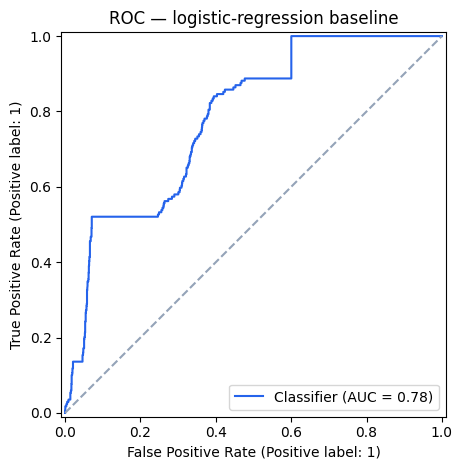

In [5]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(yte, proba, color='#2563eb')
plt.plot([0,1],[0,1],'--',color='#94a3b8'); plt.title('ROC — logistic-regression baseline')
plt.tight_layout(); plt.show()

## 5. Feature importance (coefficients)

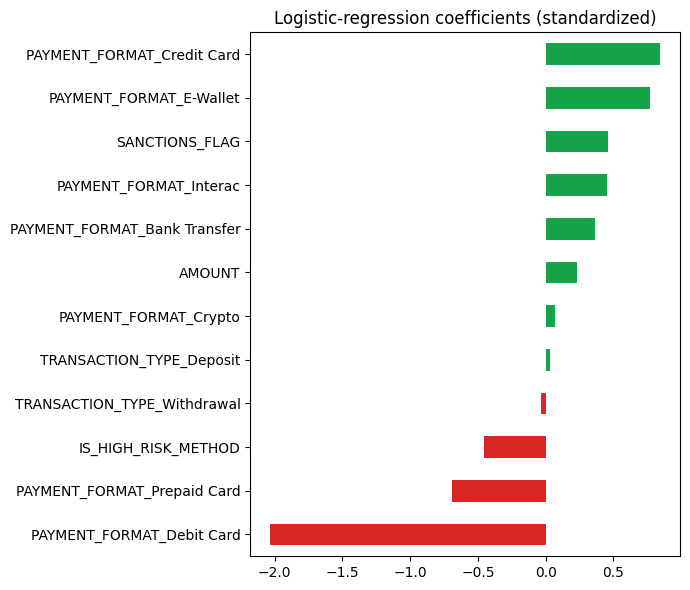

,coefficient
PAYMENT_FORMAT_Debit Card,-2.034591
PAYMENT_FORMAT_Prepaid Card,-0.692995
IS_HIGH_RISK_METHOD,-0.452517
TRANSACTION_TYPE_Withdrawal,-0.033839
TRANSACTION_TYPE_Deposit,0.033839
PAYMENT_FORMAT_Crypto,0.071323
AMOUNT,0.229271
PAYMENT_FORMAT_Bank Transfer,0.362302
PAYMENT_FORMAT_Interac,0.450577
SANCTIONS_FLAG,0.456890


In [6]:
coef = pd.Series(model.coef_[0], index=X.columns).sort_values()
ax = coef.plot.barh(figsize=(7,6), color=['#dc2626' if v<0 else '#16a34a' for v in coef])
ax.set_title('Logistic-regression coefficients (standardized)'); plt.tight_layout(); plt.show()
coef.to_frame('coefficient')

## Findings

- The logistic-regression baseline reaches **ROC-AUC 0.78** on simple transaction features — a
  useful complementary signal, though the transparent rules deliver higher recall (the
  regulatory priority).
- The strongest coefficients are `SANCTIONS_FLAG` and the structuring-linked payment methods.
- Takeaway: a **hybrid** approach — explainable rules for high-recall detection, plus an ML
  score to help prioritize/triage false positives. Optimistic by construction on synthetic data.
